# ตัวอย่าง
1. การอ่านข้อมูลจากไฟล์เช้า data frame
2. การจัดเก็บข้อมูลจาก data frame ลงบนไฟล์

# Generate Dataset

In [1]:
import pandas as pd
import numpy as np

# Generate date range from 1990 to 2024
dates = pd.date_range(start='1990-01-01', end='2024-12-01', freq='MS')

# Simulate sales data with a seasonal pattern and some noise
np.random.seed(42)  # For reproducibility
sales = np.random.randint(150, 300, size=len(dates)) + np.sin(np.linspace(0, 3 * np.pi, len(dates))) * 50

# Create a DataFrame
champagne_sales = pd.DataFrame({
    'Month': dates,
    'Sales': sales.astype(int)
})

# Set the 'Month' column as the index
champagne_sales.set_index('Month', inplace=True)

# Display the first few rows of the dataset
print(champagne_sales.head())

# Save the dataset to a CSV file
champagne_sales.to_csv('champagne_sales.csv')


            Sales
Month            
1990-01-01    252
1990-02-01    243
1990-03-01    166
1990-04-01    259
1990-05-01    225


In [ ]:
champagne_sales.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420 entries, 1990-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   420 non-null    int64
dtypes: int64(1)
memory usage: 6.6 KB


# Step 1: Data Collection
Data Loading: The data is loaded into a Pandas DataFrame. The Month column is parsed as a date and set as the index.

In [ ]:
from google.colab import files
import pandas as pd

# Upload the file from your local computer
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('champagne_sales.csv', parse_dates=['Month'], index_col='Month')

# Display the dataframe
df.head()


Saving champagne_sales.csv to champagne_sales (1).csv


,Sales
Month,
1990-01-01,252
1990-02-01,243
1990-03-01,166
1990-04-01,259
1990-05-01,225


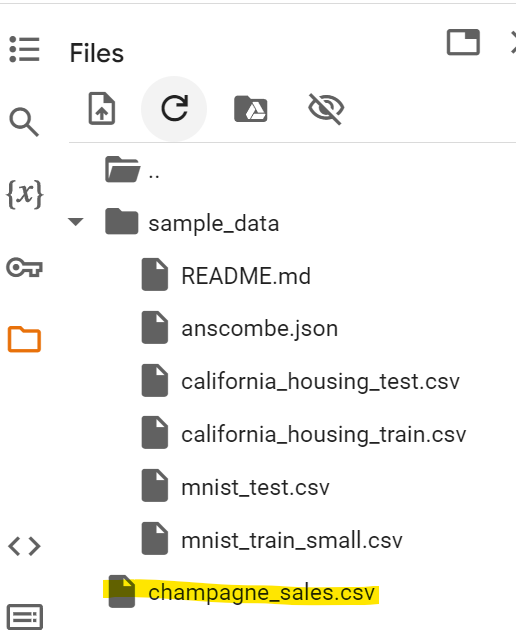

In [ ]:
#### Read file from sample_data folder
import pandas as pd

# Load the dataset from sample_data folder
df = pd.read_csv('/content/champagne_sales.csv', parse_dates=['Month'], index_col='Month')

# Display the dataframe
df.head()


,Sales
Month,
1990-01-01,252
1990-02-01,243
1990-03-01,166
1990-04-01,259
1990-05-01,225


# Step 2: Data Preprocessing
This step involves cleaning the data, handling any missing values, and ensuring the date column is properly formatted.

In [ ]:
# Check for missing data
print(df.isnull().sum())

# If there are any NaN values, drop them
df.dropna(inplace=True)

# Ensure 'Month' is in datetime format
df.index = pd.to_datetime(df.index)

# Confirm that the data is in the correct format
print(df.info())


Sales    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420 entries, 1990-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   420 non-null    int64
dtypes: int64(1)
memory usage: 6.6 KB
None


# Step 3: Data Visualization
Visualizing the data helps in understanding trends, seasonality, and any anomalies.

Plotting: The data is visualized to observe trends and patterns. This is crucial for understanding the behavior of the time series.

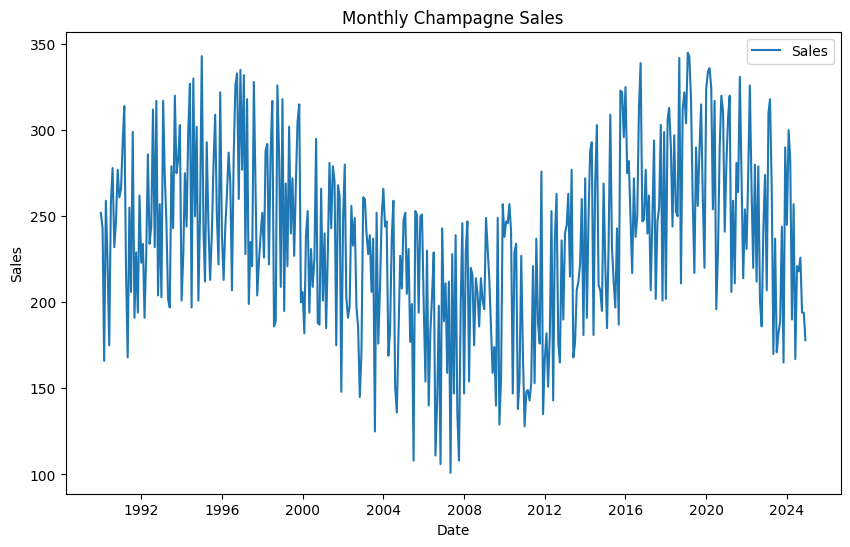

In [ ]:
import matplotlib.pyplot as plt

# Plot the sales data
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Sales'], label='Sales')
plt.title('Monthly Champagne Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


# Step 4: Stationarity Check
We need to check if the time series data is stationary, as non-stationary data can affect the performance of forecasting models.

ADF Test: The Augmented Dickey-Fuller (ADF) test is used to check if the data is stationary. If the p-value is greater than 0.05, the data is non-stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
result = adfuller(df['Sales'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Interpret the result
if result[1] > 0.05:
    print("The data is non-stationary.")
else:
    print("The data is stationary.")


ADF Statistic: -2.208625030650245
p-value: 0.2031299746543474
The data is non-stationary.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420 entries, 1990-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   420 non-null    int64
dtypes: int64(1)
memory usage: 6.6 KB


In [ ]:
df

,Sales
Month,
1990-01-01,252
1990-02-01,243
1990-03-01,166
1990-04-01,259
1990-05-01,225
...,...
2024-08-01,218
2024-09-01,226
2024-10-01,194


# Step 5: Differencing the Data
If the data is non-stationary, we apply differencing to make it stationary.

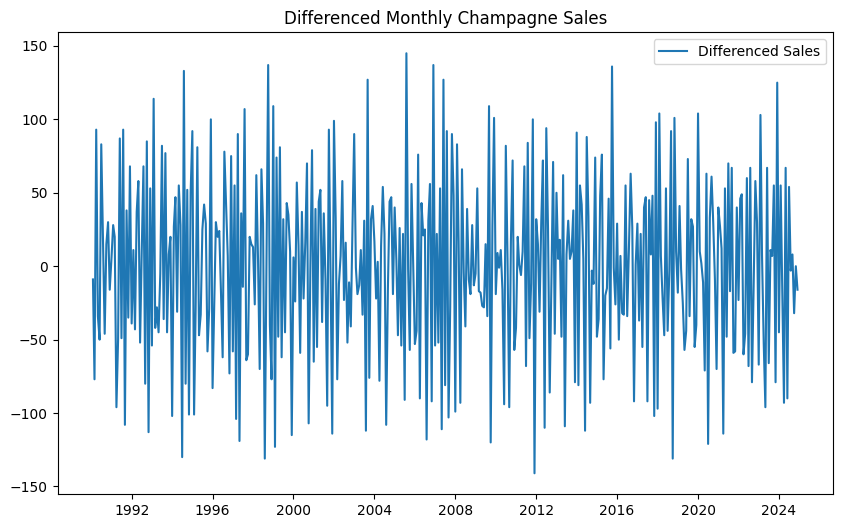

ADF Statistic: -12.139462643009312
p-value: 1.663898377435557e-22
The differenced data is stationary.


In [ ]:
df_diff = df.diff().dropna()

# Plot the differenced data
plt.figure(figsize=(10, 6))
plt.plot(df_diff.index, df_diff['Sales'], label='Differenced Sales')
plt.title('Differenced Monthly Champagne Sales')
plt.legend()
plt.show()

# Perform the ADF test again on the differenced data
result_diff = adfuller(df_diff['Sales'])
print(f'ADF Statistic: {result_diff[0]}')
print(f'p-value: {result_diff[1]}')

if result_diff[1] > 0.05:
    print("The differenced data is non-stationary.")
else:
    print("The differenced data is stationary.")


Differencing: Differencing removes trends and seasonality, making the data stationary.
ADF Test on Differenced Data: After differencing, we recheck the stationarity using the ADF test.

# Step 6: Plot ACF and PACF
Plotting the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) helps determine the AR and MA terms.

ACF and PACF Plots: The ACF plot helps identify the number of lags to include in the Moving Average (MA) model, while the PACF plot helps identify the number of lags to include in the Autoregressive (AR) model.

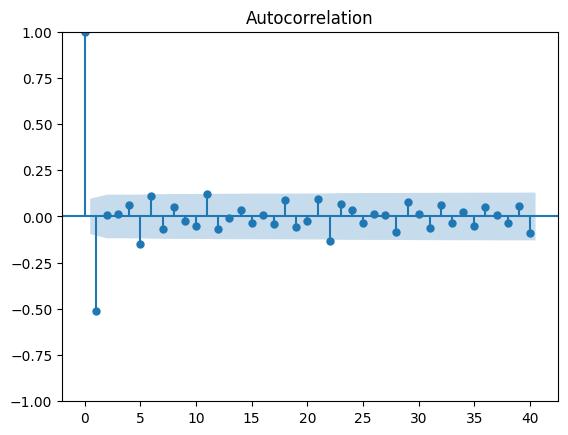

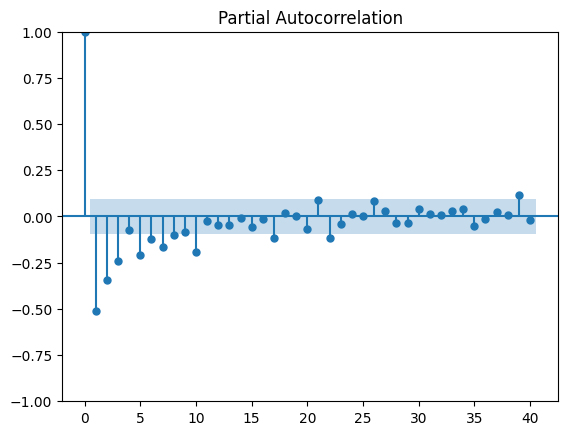

In [ ]:
import statsmodels.api as sm

# Plot ACF
sm.graphics.tsa.plot_acf(df_diff, lags=40)
plt.show()

# Plot PACF
sm.graphics.tsa.plot_pacf(df_diff, lags=40)
plt.show()


# Step 7: Model Selection and Building SARIMA Model
Based on the ACF and PACF plots, we can select the appropriate parameters and build the SARIMA model.

SARIMA Model: SARIMA (Seasonal ARIMA) incorporates both seasonal and non-seasonal components in the time series model. The parameters (p, d, q) represent the non-seasonal ARIMA terms, and (P, D, Q, s) represent the seasonal terms with s being the length of the seasonality.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build the SARIMA model
model = SARIMAX(df['Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))

# Fit the model
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  420
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2145.561
Date:                            Wed, 02 Jul 2025   AIC                           4301.122
Time:                                    07:26:35   BIC                           4321.166
Sample:                                01-01-1990   HQIC                          4309.054
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0525      0.055     -0.951      0.341      -0.161       0.056
ma.L1         -0.8928      0.029   

# Step 8: Forecasting
Once the model is fitted, we can forecast the future values.



Forecasting: The model generates forecasts for the next 12 months. The forecasted values are plotted along with confidence intervals.

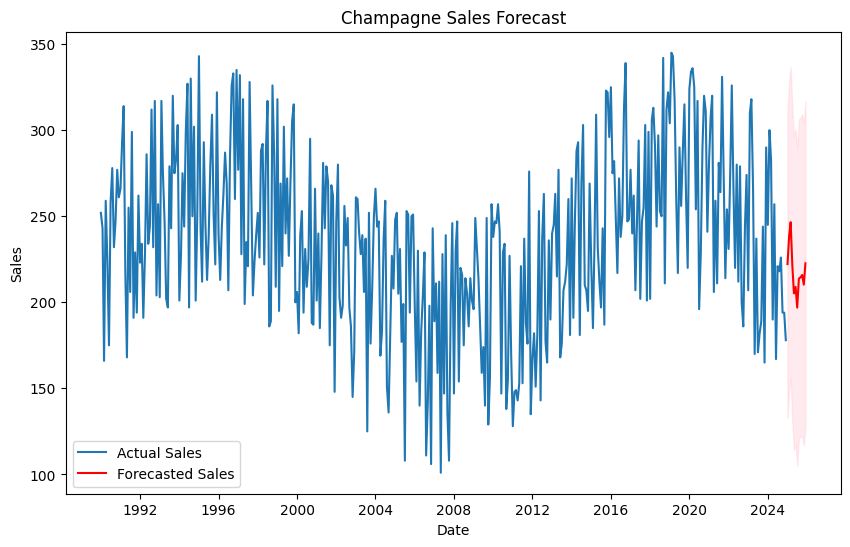

In [ ]:
# Forecast the next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_values = forecast.predicted_mean

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Sales'], label='Actual Sales')
plt.plot(forecast_values.index, forecast_values, label='Forecasted Sales', color='red')
plt.fill_between(forecast_values.index,
                 forecast.conf_int()['lower Sales'],
                 forecast.conf_int()['upper Sales'],
                 color='pink', alpha=0.3)
plt.title('Champagne Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


# Step 9: Model Evaluation
Evaluate the model's performance using metrics like Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Model Evaluation: MAE and RMSE are used to evaluate the accuracy of the model. Lower values indicate better performance.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae = mean_absolute_error(df['Sales'][-12:], forecast_values)
print(f'Mean Absolute Error: {mae}')

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(df['Sales'][-12:], forecast_values))
print(f'Root Mean Squared Error: {rmse}')


Mean Absolute Error: 30.70460425249512
Root Mean Squared Error: 34.77373702253351


# Step 10: Save Results
Finally, save the forecasted values and results to a CSV file for future reference.

In [ ]:
forecast_df = pd.DataFrame({
    'Date': forecast_values.index,
    'Forecasted Sales': forecast_values
})
forecast_df.to_csv('forecasted_champagne_sales.csv', index=False)


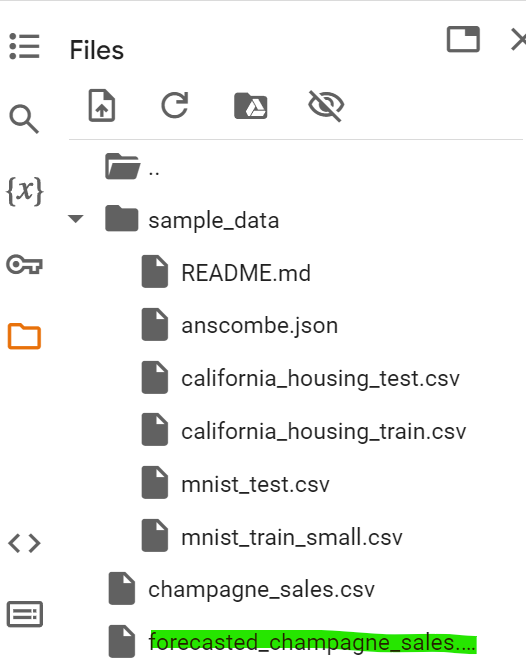